In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

## 1. Import Required Libraries

The required libraries are imported for data handling, preprocessing, model development, cross-validation, evaluation, and visualization.

Logistic Regression requires numerical input. Therefore, categorical variables will be handled using One-Hot Encoding and numerical variables will be standardized using StandardScaler.

In [2]:
df = pd.read_csv(
    "../data/processed/feature_engineered_dataset.csv"
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (119390, 35)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,is_family,service_score,customer_history,room_changed
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,0,2.0,0,0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,0,2.0,0,0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,1,1.0,0,0,0,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,1,1.0,0,0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,2,2.0,0,1,0,0


## 3. Verify the Modelling Dataset

Before model development, the dataset is checked to confirm:
- the number of records and features,
- the availability of the target variable,
- the target class distribution,
- and whether any missing values remain.

This step verifies that the feature-engineered dataset is ready for modelling.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nTarget distribution:")
print(df["is_canceled"].value_counts())

print("\nTarget distribution (%):")
print(
    df["is_canceled"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(
    "\nTotal missing values:",
    df.isnull().sum().sum()
)

Number of rows: 119390
Number of columns: 35

Target distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Target distribution (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64

Total missing values: 0


## 4. Separate Predictors and Target

The target variable is `is_canceled`.

- `X` contains the predictor features used as inputs to the model.
- `y` contains the target variable that the model must predict.

The target is removed from the predictor set to prevent the model from directly receiving the correct cancellation outcome.

In [4]:
X = df.drop(columns=["is_canceled"])
y = df["is_canceled"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (119390, 34)
Target shape: (119390,)


## 5. Create the Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 stratified split.

- 80% of the data is used for model development.
- 20% is reserved as the final hold-out test set.
- `random_state=42` ensures reproducibility.
- `stratify=y` preserves the cancellation class distribution in both subsets.

The test set will remain independent and will not be used for hyperparameter tuning.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (95512, 34)
X_test: (23878, 34)
y_train: (95512,)
y_test: (23878,)


### Verify the Class Distribution After Splitting

Stratification is used to maintain approximately the same proportion of cancelled and non-cancelled bookings in both the training and testing datasets.

In [6]:
print("Training target distribution (%):")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution (%):")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training target distribution (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64

Testing target distribution (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


## 6. Identify Numerical and Categorical Features

The predictor variables contain both numerical and categorical features.

Different preprocessing techniques are required:

- Categorical features will be transformed using One-Hot Encoding.
- Numerical features will be standardized using StandardScaler.

The feature groups are identified using the training dataset.

In [7]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print(
    "Number of categorical features:",
    len(categorical_cols)
)

print(
    "Number of numerical features:",
    len(numerical_cols)
)

print("\nCategorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numerical_cols)

Number of categorical features: 10
Number of numerical features: 24

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'is_family', 'service_score', 'customer_history', 'room_changed']


## 7. Build the Preprocessing Pipeline

Logistic Regression requires numerical input.

Two different preprocessing techniques are applied:

- **Categorical features:** One-Hot Encoding is used to convert categories into numerical indicator variables.
- **Numerical features:** StandardScaler is used to standardize numerical values.

ColumnTransformer allows both transformations to be applied to the appropriate feature groups.

The preprocessing steps are kept inside the modelling pipeline so that the transformations are learned only from training data during model development and cross-validation.

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_cols
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 8. Create the Baseline Logistic Regression Pipeline

A baseline Logistic Regression model is created before hyperparameter tuning.

The pipeline combines preprocessing and classification into a single workflow:

1. Apply One-Hot Encoding to categorical features.
2. Apply StandardScaler to numerical features.
3. Train the Logistic Regression classifier.

This pipeline helps ensure that preprocessing is applied consistently during cross-validation and later prediction.

In [9]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Baseline Logistic Regression pipeline created.")

Baseline Logistic Regression pipeline created.


## 9. Define the Cross-Validation Strategy

The baseline Logistic Regression model is evaluated using 5-fold Stratified Cross-Validation on the training data.

The training dataset is divided into five folds. In each iteration:

- Four folds are used for training.
- One fold is used for validation.
- The validation fold changes across the five iterations.
- Stratification preserves the cancellation class distribution in each fold.

The final hold-out test dataset is not used during cross-validation.

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold Stratified Cross-Validation configured.")

5-fold Stratified Cross-Validation configured.


## 10. Define the Evaluation Metrics

Multiple evaluation metrics are used because accuracy alone is not sufficient to fully evaluate a classification model.

The following metrics are used:

- **Accuracy:** Overall proportion of correct predictions.
- **Precision:** Among bookings predicted as cancelled, how many were actually cancelled.
- **Recall:** Among all actual cancelled bookings, how many were correctly identified.
- **F1-score:** Balance between Precision and Recall.
- **ROC-AUC:** Measures the ability of the model to distinguish between cancelled and non-cancelled bookings across classification thresholds.

In [11]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("Evaluation metrics configured.")

Evaluation metrics configured.


## 11. Evaluate the Baseline Logistic Regression Model

The baseline Logistic Regression pipeline is evaluated using 5-fold Stratified Cross-Validation on the training dataset.

Preprocessing and model fitting are performed within the pipeline for each cross-validation fold.

Both training and validation scores are recorded to help identify possible overfitting or underfitting.

The final test dataset remains unseen at this stage.

In [12]:
start_time = time.time()

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

cv_time = time.time() - start_time

print(
    f"Cross-validation completed in "
    f"{cv_time:.2f} seconds."
)

Cross-validation completed in 6.47 seconds.


## 12. Baseline Cross-Validation Results

The baseline Logistic Regression model was evaluated across five stratified cross-validation folds.

For each evaluation metric:

- **CV Mean** represents the average validation performance across the five folds.
- **CV Standard Deviation** shows how much the validation performance varies between folds.
- **Train Mean** represents the average performance on the training portions of the folds.

Training and validation scores are compared to investigate whether the baseline model shows signs of overfitting or underfitting.

In [13]:
metric_names = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

print("Baseline Logistic Regression")
print("=" * 70)

for metric in metric_names:
    cv_scores = cv_results[f"test_{metric}"]
    train_scores = cv_results[f"train_{metric}"]

    print(
        f"{metric.upper():10} | "
        f"CV Mean: {cv_scores.mean():.4f} | "
        f"CV Std: {cv_scores.std():.4f} | "
        f"Train Mean: {train_scores.mean():.4f}"
    )

print("=" * 70)
print(
    f"Total Cross-Validation Time: "
    f"{cv_time:.2f} seconds"
)


Baseline Logistic Regression
ACCURACY   | CV Mean: 0.8204 | CV Std: 0.0030 | Train Mean: 0.8216
PRECISION  | CV Mean: 0.8104 | CV Std: 0.0051 | Train Mean: 0.8122
RECALL     | CV Mean: 0.6724 | CV Std: 0.0050 | Train Mean: 0.6745
F1         | CV Mean: 0.7350 | CV Std: 0.0045 | Train Mean: 0.7369
ROC_AUC    | CV Mean: 0.9005 | CV Std: 0.0021 | Train Mean: 0.9017
Total Cross-Validation Time: 6.47 seconds


## 13. Baseline Model Interpretation

The baseline Logistic Regression model achieved consistent performance across the five cross-validation folds.

The training and cross-validation scores are very close, which indicates that there is no strong evidence of overfitting in the baseline model.

Key observations:

- Mean CV Accuracy: approximately 82.04%
- Mean CV Precision: approximately 81.04%
- Mean CV Recall: approximately 67.24%
- Mean CV F1-score: approximately 73.50%
- Mean CV ROC-AUC: approximately 90.05%

The low cross-validation standard deviations indicate that the model performs consistently across the five folds.

Precision is higher than Recall. This indicates that predictions classified as cancellations are relatively reliable, but the model does not identify all actual cancellations.

Therefore, hyperparameter tuning will investigate whether the balance between Precision and Recall, particularly cancellation detection, can be improved without causing overfitting.

## 14. Hyperparameter Tuning

The baseline Logistic Regression model achieved stable cross-validation performance, but Recall was lower than Precision.

Hyperparameter tuning is performed to investigate whether the Logistic Regression configuration can provide a better balance between Precision and Recall while maintaining good generalization.

GridSearchCV is used to evaluate different hyperparameter combinations using 5-fold Stratified Cross-Validation on the training data only.

The final hold-out test set is not used during hyperparameter tuning.

In [14]:
from sklearn.model_selection import GridSearchCV

### Define the Hyperparameter Search Space

The following Logistic Regression hyperparameters are investigated:

- **C:** Controls regularization strength. Smaller values apply stronger regularization.
- **penalty:** Specifies the type of regularization applied to the model.
- **solver:** Specifies the optimization algorithm used to train Logistic Regression.
- **class_weight:** Investigates whether automatically balancing the target classes improves cancellation detection.

Only compatible solver and penalty combinations are included.

In [15]:
param_grid = [
    {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear"],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
        "model__class_weight": [None, "balanced"]
    }
]

print("Hyperparameter search space configured.")

Hyperparameter search space configured.


### Configure GridSearchCV

GridSearchCV is used to systematically evaluate the defined Logistic Regression hyperparameter combinations.

F1-score is used as the primary optimization metric because it provides a balance between Precision and Recall.

This is particularly useful for the baseline model because Precision was higher than Recall.

The search uses 5-fold Stratified Cross-Validation on the training dataset only.

The final hold-out test dataset is not used during hyperparameter selection.

In [16]:
grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("GridSearchCV configured successfully.")

GridSearchCV configured successfully.


## 15. Run Hyperparameter Tuning

The defined Logistic Regression configurations are evaluated using 5-fold Stratified Cross-Validation on the training dataset.

GridSearchCV identifies the configuration with the highest mean cross-validation F1-score.

The final hold-out test set remains unseen during this process.

In [17]:
tuning_start_time = time.time()

grid_search.fit(
    X_train,
    y_train
)

tuning_time = time.time() - tuning_start_time

print(
    f"Hyperparameter tuning completed in "
    f"{tuning_time:.2f} seconds."
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Hyperparameter tuning completed in 455.87 seconds.


## 16. Best Hyperparameter Configuration

After evaluating all candidate configurations using 5-fold Stratified Cross-Validation, GridSearchCV selects the configuration with the highest mean cross-validation F1-score.

The selected hyperparameters are examined before performing the final hold-out test evaluation.

In [18]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

print(
    "\nBest Cross-Validation F1-score:",
    round(grid_search.best_score_, 4)
)

print(
    "Hyperparameter Tuning Time:",
    round(tuning_time, 2),
    "seconds"
)

Best Hyperparameters:
{'model__C': 1, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}

Best Cross-Validation F1-score: 0.7598
Hyperparameter Tuning Time: 455.87 seconds


### Store the Best Logistic Regression Pipeline

The best pipeline identified by GridSearchCV is stored for further cross-validation analysis.

This pipeline contains both the selected preprocessing workflow and the Logistic Regression configuration selected during hyperparameter tuning.

In [19]:
best_model = grid_search.best_estimator_

print("Best Logistic Regression pipeline stored successfully.")

Best Logistic Regression pipeline stored successfully.


## 17. Evaluate the Tuned Logistic Regression Model

The best Logistic Regression pipeline selected by GridSearchCV is evaluated using the same 5-fold Stratified Cross-Validation strategy.

This allows the tuned model to be compared fairly with the baseline model using the same training data, validation strategy, and evaluation metrics.

The final hold-out test set remains unseen at this stage.

In [20]:
tuned_cv_start_time = time.time()

tuned_cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

tuned_cv_time = time.time() - tuned_cv_start_time

print(
    f"Tuned model cross-validation completed in "
    f"{tuned_cv_time:.2f} seconds."
)

Tuned model cross-validation completed in 65.62 seconds.


## 18. Tuned Cross-Validation Results

The tuned Logistic Regression model is evaluated using the same 5-fold Stratified Cross-Validation strategy as the baseline model.

Using the same validation procedure allows a fair comparison between the baseline and tuned models.

The mean validation score, standard deviation, and mean training score are reported for each evaluation metric.

In [21]:
print("Tuned Logistic Regression")
print("=" * 70)

for metric in metric_names:
    cv_scores = tuned_cv_results[f"test_{metric}"]
    train_scores = tuned_cv_results[f"train_{metric}"]

    print(
        f"{metric.upper():10} | "
        f"CV Mean: {cv_scores.mean():.4f} | "
        f"CV Std: {cv_scores.std():.4f} | "
        f"Train Mean: {train_scores.mean():.4f}"
    )

print("=" * 70)
print(
    f"Total Tuned Cross-Validation Time: "
    f"{tuned_cv_time:.2f} seconds"
)

Tuned Logistic Regression
ACCURACY   | CV Mean: 0.8142 | CV Std: 0.0019 | Train Mean: 0.8157
PRECISION  | CV Mean: 0.7290 | CV Std: 0.0017 | Train Mean: 0.7308
RECALL     | CV Mean: 0.7934 | CV Std: 0.0057 | Train Mean: 0.7953
F1         | CV Mean: 0.7598 | CV Std: 0.0031 | Train Mean: 0.7617
ROC_AUC    | CV Mean: 0.9007 | CV Std: 0.0022 | Train Mean: 0.9020
Total Tuned Cross-Validation Time: 65.62 seconds


## 19. Baseline vs Tuned Model Comparison

The baseline and tuned Logistic Regression models are compared using the same 5-fold Stratified Cross-Validation strategy.

Hyperparameter tuning improved Recall and F1-score, while Precision and overall Accuracy decreased slightly.

This indicates a trade-off: the tuned model identifies a larger proportion of actual cancellations, but it also produces more false-positive cancellation predictions.

The ROC-AUC remained approximately stable, indicating that the overall ability to distinguish between cancelled and non-cancelled bookings was maintained.

In [22]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline CV": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Tuned CV": [
        tuned_cv_results["test_accuracy"].mean(),
        tuned_cv_results["test_precision"].mean(),
        tuned_cv_results["test_recall"].mean(),
        tuned_cv_results["test_f1"].mean(),
        tuned_cv_results["test_roc_auc"].mean()
    ]
})

comparison_df["Difference"] = (
    comparison_df["Tuned CV"]
    - comparison_df["Baseline CV"]
)

comparison_df.round(4)

,Metric,Baseline CV,Tuned CV,Difference
0,Accuracy,0.8204,0.8142,-0.0062
1,Precision,0.8104,0.7290,-0.0814
2,Recall,0.6724,0.7934,0.1210
3,F1,0.7350,0.7598,0.0248
4,ROC-AUC,0.9005,0.9007,0.0002


## 20. Selected Logistic Regression Configuration

The tuned Logistic Regression model is selected as the final Logistic Regression configuration for hold-out testing.

Selected hyperparameters:

- `C = 1`
- `class_weight = "balanced"`
- `penalty = "l1"`
- `solver = "liblinear"`

Compared with the baseline model:

- Recall increased from approximately 67.24% to 79.34%.
- F1-score increased from approximately 73.50% to 75.98%.
- ROC-AUC remained approximately stable.
- Precision decreased from approximately 81.04% to 72.90%.
- Accuracy decreased slightly from approximately 82.04% to 81.42%.

Therefore, tuning produced a Precision-Recall trade-off. The tuned model identifies a substantially larger proportion of actual cancellations while generating more false-positive cancellation predictions.

Since F1-score was used as the primary tuning metric, the tuned configuration is selected and frozen before final hold-out test evaluation.

## 21. Final Hold-Out Test Evaluation

After hyperparameter tuning and model selection, the selected Logistic Regression pipeline is evaluated on the independent hold-out test dataset.

The test dataset was not used for hyperparameter tuning.

This provides an estimate of how the selected Logistic Regression model performs on unseen booking records.

In [23]:
final_start_time = time.time()

best_model.fit(
    X_train,
    y_train
)

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(
    X_test
)[:, 1]

final_prediction_time = (
    time.time() - final_start_time
)

print(
    "Final model fitted and "
    "test predictions generated."
)

print(
    f"Final fitting and prediction time: "
    f"{final_prediction_time:.2f} seconds"
)

Final model fitted and test predictions generated.
Final fitting and prediction time: 59.81 seconds


## 22. Final Test Performance

The selected Logistic Regression model is now evaluated on the independent hold-out test dataset.

The following metrics are used to measure final predictive performance:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

These results represent the performance of the selected Logistic Regression configuration on previously unseen booking records.

In [24]:
final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Final Logistic Regression Test Results")
print("=" * 50)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")

print("=" * 50)

Final Logistic Regression Test Results
Accuracy : 0.8126
Precision: 0.7294
Recall   : 0.7858
F1-score : 0.7565
ROC-AUC  : 0.8991


## 23. Confusion Matrix

The confusion matrix is used to examine the types of predictions made by the final Logistic Regression model.

It shows:

- **True Negative (TN):** Correctly predicted non-cancelled bookings.
- **False Positive (FP):** Predicted as cancelled but actually not cancelled.
- **False Negative (FN):** Predicted as not cancelled but actually cancelled.
- **True Positive (TP):** Correctly predicted cancelled bookings.

False Negatives are particularly important because they represent actual cancellations that the model failed to identify.

Confusion Matrix
[[12454  2579]
 [ 1895  6950]]

True Negatives : 12454
False Positives: 2579
False Negatives: 1895
True Positives : 6950


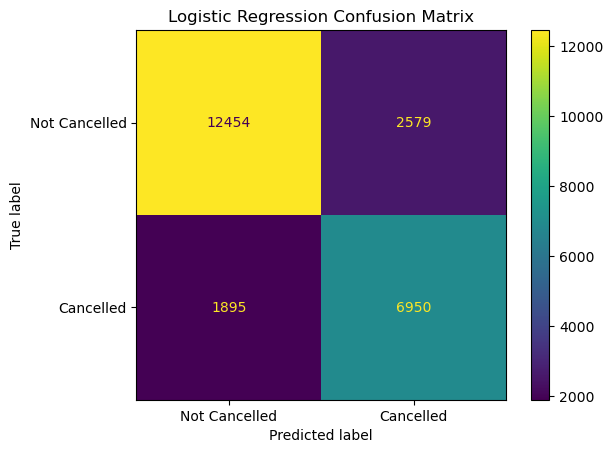

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Cancelled",
        "Cancelled"
    ]
).plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

## 24. Classification Report

The classification report provides class-specific Precision, Recall, F1-score, and support.

This helps evaluate how the model performs separately for non-cancelled and cancelled bookings rather than relying only on overall Accuracy.

In [26]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Cancelled",
            "Cancelled"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

Not Cancelled       0.87      0.83      0.85     15033
    Cancelled       0.73      0.79      0.76      8845

     accuracy                           0.81     23878
    macro avg       0.80      0.81      0.80     23878
 weighted avg       0.82      0.81      0.81     23878



## 25. ROC Curve

The ROC curve evaluates the ability of the Logistic Regression model to distinguish between cancelled and non-cancelled bookings across different classification thresholds.

The ROC-AUC score summarizes this discrimination ability.

The final Logistic Regression model achieved an ROC-AUC of approximately 0.8991 on the hold-out test dataset.

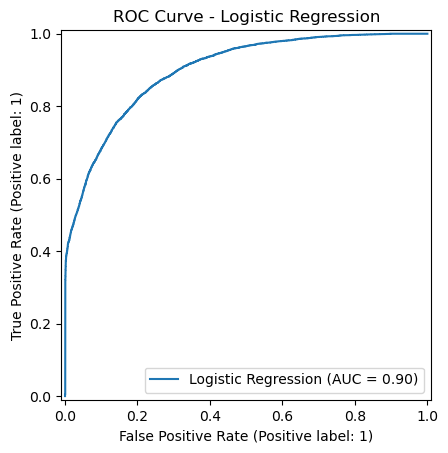

In [27]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Logistic Regression"
)

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.show()

## 26. Confusion Matrix Interpretation

The final Logistic Regression model produced the following confusion matrix results:

- True Negatives (TN): 12,454
- False Positives (FP): 2,579
- False Negatives (FN): 1,895
- True Positives (TP): 6,950

The model correctly predicted 12,454 non-cancelled bookings and correctly identified 6,950 cancelled bookings.

However, 2,579 non-cancelled bookings were incorrectly predicted as cancellations, while 1,895 actual cancellations were missed by the model.

For the cancelled class, the model achieved approximately 79% Recall. Therefore, the model successfully detected a substantial proportion of actual cancellations, although some cancellations were still missed.

## 27. Final Logistic Regression Conclusion

The Logistic Regression model was developed using a leakage-controlled preprocessing and modelling pipeline.

Categorical variables were transformed using One-Hot Encoding, while numerical variables were standardized using StandardScaler.

The baseline model was evaluated using 5-fold Stratified Cross-Validation. Hyperparameter tuning was then performed using GridSearchCV on the training dataset only.

The selected Logistic Regression configuration was:

- `C = 1`
- `class_weight = "balanced"`
- `penalty = "l1"`
- `solver = "liblinear"`

Hyperparameter tuning improved the mean cross-validation Recall from approximately 67.24% to 79.34% and improved the F1-score from approximately 73.50% to 75.98%.

This improvement introduced a Precision-Recall trade-off. Precision decreased while Recall increased, meaning that the tuned model detected more actual cancellations but also produced more false-positive cancellation predictions.

### Final Hold-Out Test Results

- Accuracy: 81.26%
- Precision: 72.94%
- Recall: 78.58%
- F1-score: 75.65%
- ROC-AUC: 89.91%

The final hold-out results are close to the tuned cross-validation results. This indicates stable generalization and no strong evidence of overfitting.

The confusion matrix showed:

- 12,454 True Negatives
- 2,579 False Positives
- 1,895 False Negatives
- 6,950 True Positives

Logistic Regression therefore provides a strong and interpretable candidate model for hotel booking cancellation prediction.

However, Logistic Regression is not yet declared the final project model. Final model selection will be performed after comparing Logistic Regression with Decision Tree, Random Forest, and K-Nearest Neighbors using the common team evaluation protocol.

## 28. Logistic Regression Result Summary

A compact result summary is prepared for later comparison with the other candidate machine-learning models.

In [28]:
result_summary = pd.DataFrame({
    "Member": ["Member 01"],
    "Model": ["Logistic Regression"],

    "Best_C": [1],
    "Best_Class_Weight": ["balanced"],
    "Best_Penalty": ["l1"],
    "Best_Solver": ["liblinear"],

    "CV_Accuracy": [
        tuned_cv_results["test_accuracy"].mean()
    ],
    "CV_Precision": [
        tuned_cv_results["test_precision"].mean()
    ],
    "CV_Recall": [
        tuned_cv_results["test_recall"].mean()
    ],
    "CV_F1": [
        tuned_cv_results["test_f1"].mean()
    ],
    "CV_ROC_AUC": [
        tuned_cv_results["test_roc_auc"].mean()
    ],

    "Test_Accuracy": [final_accuracy],
    "Test_Precision": [final_precision],
    "Test_Recall": [final_recall],
    "Test_F1": [final_f1],
    "Test_ROC_AUC": [final_roc_auc],

    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp]
})

result_summary.round(4)

,Member,Model,Best_C,Best_Class_Weight,Best_Penalty,Best_Solver,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,TN,FP,FN,TP
0,Member 01,Logistic Regression,1,balanced,l1,liblinear,0.8142,0.729,0.7934,0.7598,0.9007,0.8126,0.7294,0.7858,0.7565,0.8991,12454,2579,1895,6950


## 29. Save Logistic Regression Results

The final Logistic Regression result summary is saved for the team-level model comparison stage.

This result file will later be combined with the Decision Tree, Random Forest, and K-Nearest Neighbors results for final model comparison and selection.

In [29]:
result_summary.to_csv(
    "../results/logistic_regression_results.csv",
    index=False
)

print(
    "Logistic Regression results saved successfully."
)

Logistic Regression results saved successfully.
